Saving embc.csv to embc.csv
   Altitude    Az
0     73.18 -0.56
1     73.36 -0.59
2     73.35 -0.57
3     73.18 -0.55
4     73.27 -0.57


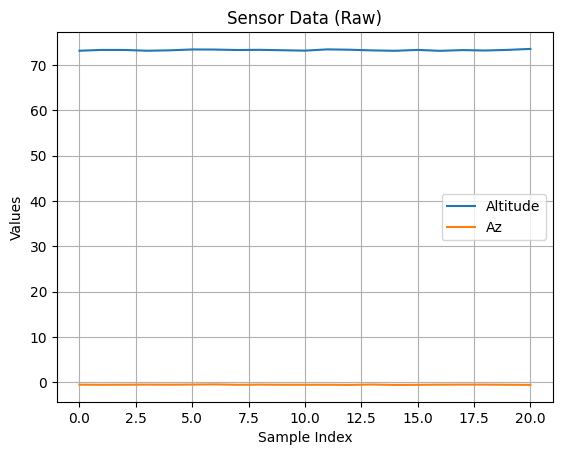

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Step 1: Upload file
from google.colab import files
uploaded = files.upload()

# Step 2: Read CSV
df = pd.read_csv('embc.csv')

# Step 3: Display first few rows
print(df.head())

# Step 4: Plot raw signals
plt.figure()
plt.plot(df['Altitude'], label='Altitude')
plt.plot(df['Az'], label='Az')

plt.title("Sensor Data (Raw)")
plt.xlabel("Sample Index")
plt.ylabel("Values")
plt.legend()
plt.grid()

plt.show()

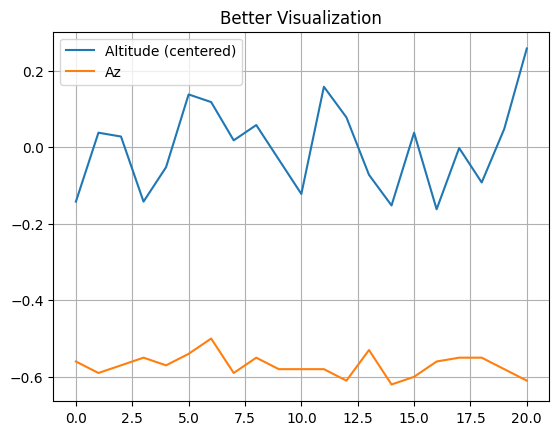

In [ ]:
import matplotlib.pyplot as plt

plt.figure()

alt_centered = df['Altitude'] - df['Altitude'].mean()

plt.plot(alt_centered, label='Altitude (centered)')
plt.plot(df['Az'], label='Az')

plt.title("Better Visualization")
plt.legend()
plt.grid()

plt.show()

In [ ]:
import kagglehub

# Download dataset
path = kagglehub.dataset_download('muthuj7/weather-dataset')

print("Data source import complete.")
print("Dataset path:", path)

100%|██████████| 2.23M/2.23M [00:01<00:00, 2.07MB/s]

Extracting files...
Data source import complete.
Dataset path: /root/.cache/kagglehub/datasets/muthuj7/weather-dataset/versions/1


In [ ]:
import os

print(os.listdir(path))

['weatherHistory.csv']


In [ ]:
import pandas as pd

weather = pd.read_csv(os.path.join(path, 'weatherHistory.csv'))

weather.head()

,Formatted Date,Summary,Precip Type,Temperature (C),Apparent Temperature (C),Humidity,Wind Speed (km/h),Wind Bearing (degrees),Visibility (km),Loud Cover,Pressure (millibars),Daily Summary
0,2006-04-01 00:00:00.000 +0200,Partly Cloudy,rain,9.472222,7.388889,0.89,14.1197,251.0,15.8263,0.0,1015.13,Partly cloudy throughout the day.
1,2006-04-01 01:00:00.000 +0200,Partly Cloudy,rain,9.355556,7.227778,0.86,14.2646,259.0,15.8263,0.0,1015.63,Partly cloudy throughout the day.
2,2006-04-01 02:00:00.000 +0200,Mostly Cloudy,rain,9.377778,9.377778,0.89,3.9284,204.0,14.9569,0.0,1015.94,Partly cloudy throughout the day.
3,2006-04-01 03:00:00.000 +0200,Partly Cloudy,rain,8.288889,5.944444,0.83,14.1036,269.0,15.8263,0.0,1016.41,Partly cloudy throughout the day.
4,2006-04-01 04:00:00.000 +0200,Mostly Cloudy,rain,8.755556,6.977778,0.83,11.0446,259.0,15.8263,0.0,1016.51,Partly cloudy throughout the day.


In [ ]:
import numpy as np

# Wind → IMU noise
wind_std = weather['Wind Speed (km/h)'].std()

# Temperature → drift
temp_std = weather['Temperature (C)'].std()

print("Wind std:", wind_std)
print("Temp std:", temp_std)

Wind std: 6.9135710125921515
Temp std: 9.551546320656923


In [ ]:
az_noise = np.random.normal(0, wind_std * 0.05, len(df))

In [ ]:
drift = np.cumsum(np.random.normal(0, temp_std * 0.0005, len(df)))

In [ ]:
df['Az_noisy'] = df['Az'] + az_noise
df['Altitude_noisy'] = df['Altitude'] + drift

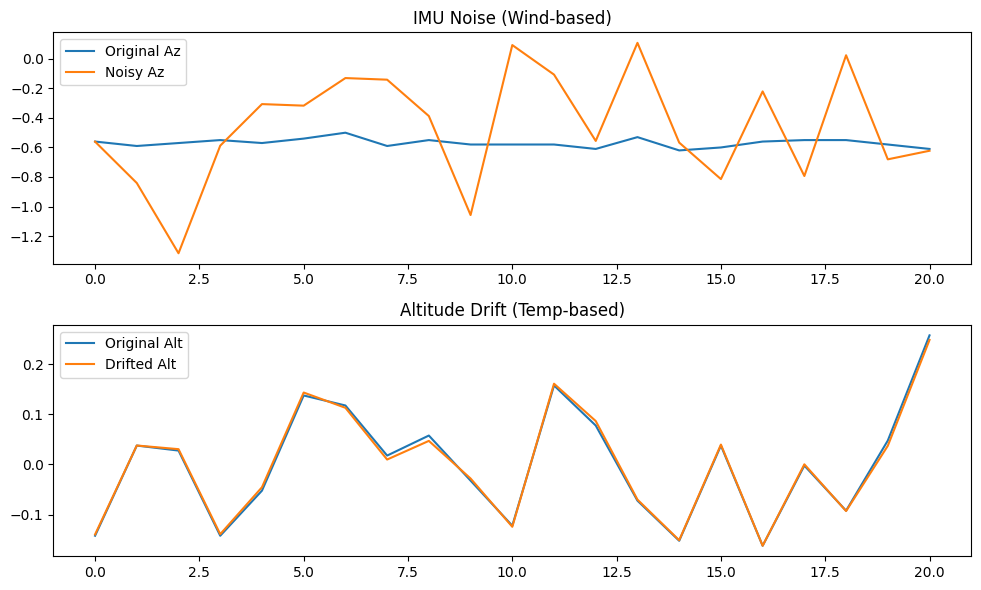

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

# Az
plt.subplot(2,1,1)
plt.plot(df['Az'], label='Original Az')
plt.plot(df['Az_noisy'], label='Noisy Az')
plt.legend()
plt.title("IMU Noise (Wind-based)")

# Altitude
plt.subplot(2,1,2)
plt.plot(df['Altitude'] - df['Altitude'].mean(), label='Original Alt')
plt.plot(df['Altitude_noisy'] - df['Altitude_noisy'].mean(), label='Drifted Alt')
plt.legend()
plt.title("Altitude Drift (Temp-based)")

plt.tight_layout()
plt.show()

In [ ]:
wind_segment = weather['Wind Speed (km/h)'].values[:len(df)]

In [ ]:
wind_norm = (wind_segment - wind_segment.mean()) / wind_segment.std()

In [ ]:
az_noise = wind_norm * 2.0   # BIG change (tune 1–3)

In [ ]:
df['Az_noisy'] = df['Az'] + az_noise

In [ ]:
temp_segment = weather['Temperature (C)'].values[:len(df)]

temp_norm = (temp_segment - temp_segment.mean()) / temp_segment.std()

drift = np.cumsum(temp_norm * 0.01)   # stronger drift

df['Altitude_noisy'] = df['Altitude'] + drift

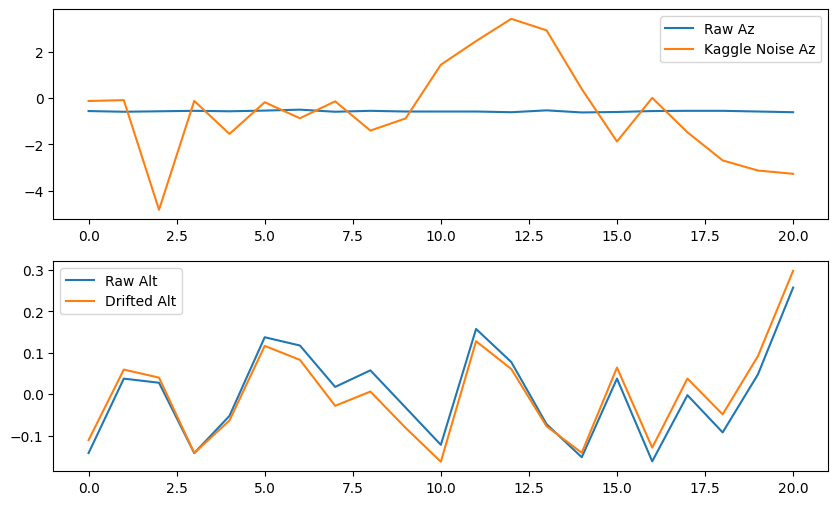

In [ ]:
plt.figure(figsize=(10,6))

plt.subplot(2,1,1)
plt.plot(df['Az'], label='Raw Az')
plt.plot(df['Az_noisy'], label='Kaggle Noise Az')
plt.legend()

plt.subplot(2,1,2)
plt.plot(df['Altitude'] - df['Altitude'].mean(), label='Raw Alt')
plt.plot(df['Altitude_noisy'] - df['Altitude_noisy'].mean(), label='Drifted Alt')
plt.legend()

plt.show()

In [ ]:
# Wind
wind = weather['Wind Speed (km/h)']
sigma_wind = wind.std()

# Temperature
temp = weather['Temperature (C)']
sigma_temp = temp.std()

print("Wind std:", sigma_wind)
print("Temp std:", sigma_temp)

Wind std: 6.9135710125921515
Temp std: 9.551546320656923


In [ ]:
N = len(df)
t = np.arange(N)
dt = 0.1

# Gaussian (wind)
w = np.random.normal(0, 1, N)
v_gauss = sigma_wind * 0.1 * w

# Oscillation
f = 1  # Hz
omega = 2 * np.pi * f
v_osc = sigma_wind * 0.1 * np.sin(omega * t * dt)

# Spikes
v_spike = np.random.uniform(-2*sigma_wind*0.1, 2*sigma_wind*0.1, N)

# Drift
temp_segment = temp.values[:N]
temp_norm = (temp_segment - temp_segment.mean()) / temp_segment.std()
beta = sigma_temp * 0.0005
drift = np.cumsum(beta * temp_norm)

In [ ]:
v_total = v_gauss + v_osc + v_spike + drift

df['Az_noisy'] = df['Az'] + v_total

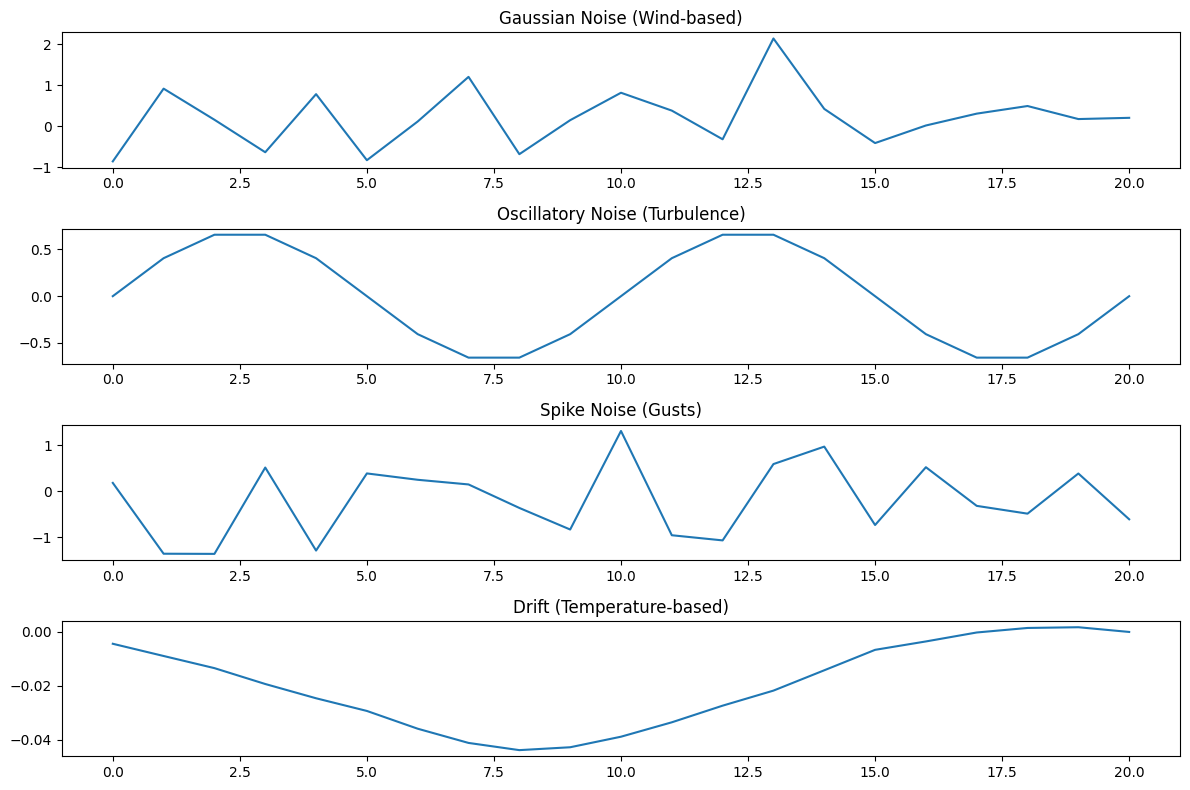

In [ ]:
plt.figure(figsize=(12,8))

plt.subplot(4,1,1)
plt.plot(v_gauss)
plt.title("Gaussian Noise (Wind-based)")

plt.subplot(4,1,2)
plt.plot(v_osc)
plt.title("Oscillatory Noise (Turbulence)")

plt.subplot(4,1,3)
plt.plot(v_spike)
plt.title("Spike Noise (Gusts)")

plt.subplot(4,1,4)
plt.plot(drift)
plt.title("Drift (Temperature-based)")

plt.tight_layout()
plt.show()

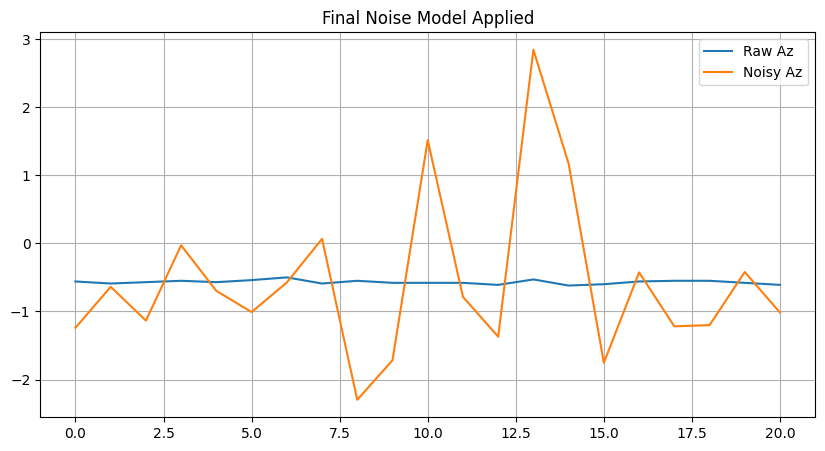

In [ ]:
plt.figure(figsize=(10,5))

plt.plot(df['Az'], label='Raw Az')
plt.plot(df['Az_noisy'], label='Noisy Az')

plt.title("Final Noise Model Applied")
plt.legend()
plt.grid()

plt.show()

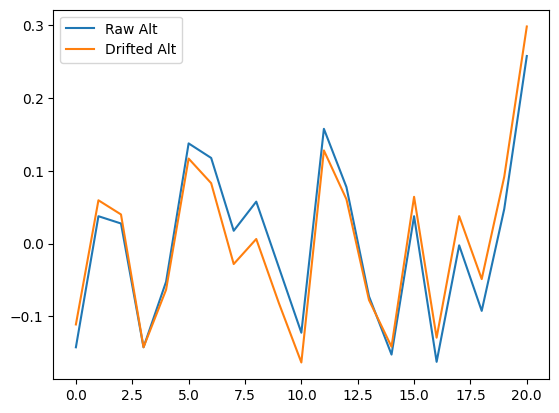

In [ ]:
plt.plot(df['Altitude'] - df['Altitude'].mean(), label='Raw Alt')
plt.plot(df['Altitude_noisy'] - df['Altitude_noisy'].mean(), label='Drifted Alt')
plt.legend()

plt.show()

Using Colab cache for faster access to the 'weather-dataset' dataset.


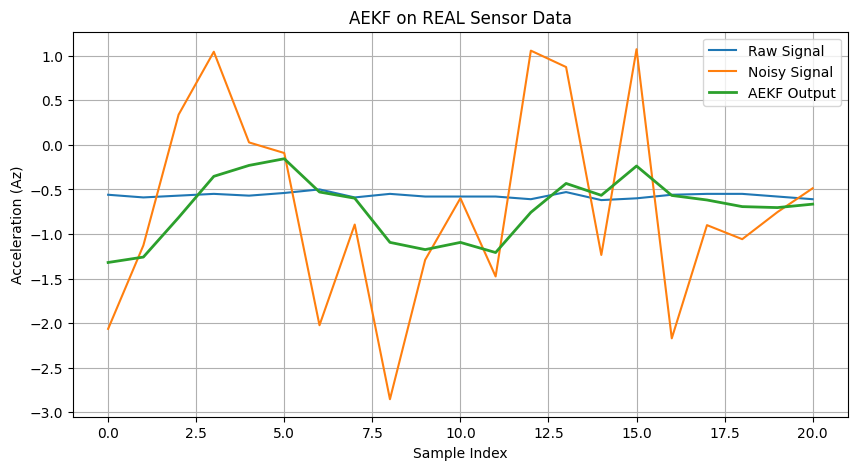

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import kagglehub
import os

# -----------------------------
# 1. LOAD YOUR SENSOR DATA
# -----------------------------

# Ensure columns exist
z_raw = df['Az'].values   # use Az as signal

N = len(z_raw)
dt = 0.1

# -----------------------------
# 2. LOAD KAGGLE DATA
# -----------------------------
path = kagglehub.dataset_download('muthuj7/weather-dataset')
weather = pd.read_csv(os.path.join(path, 'weatherHistory.csv'))

# Extract stats
wind = weather['Wind Speed (km/h)']
temp = weather['Temperature (C)']

sigma_wind = wind.std()
sigma_temp = temp.std()

# -----------------------------
# 3. CREATE REALISTIC NOISE
# -----------------------------
t = np.arange(N)

# Gaussian
v_gauss = np.random.normal(0, sigma_wind * 0.1, N)

# Oscillation
v_osc = sigma_wind * 0.1 * np.sin(2*np.pi*1*t*dt)

# Spikes
v_spike = np.random.uniform(-2*sigma_wind*0.1, 2*sigma_wind*0.1, N)

# Drift
temp_segment = temp.values[:N]
temp_norm = (temp_segment - temp_segment.mean()) / temp_segment.std()
drift = np.cumsum(temp_norm * sigma_temp * 0.0005)

# Total noise
noise = v_gauss + v_osc + v_spike + drift

z_meas = z_raw + noise

# -----------------------------
# 4. AEKF INITIALIZATION
# -----------------------------
x = np.array([[z_raw[0]], [0]])   # [position, velocity]
P = np.eye(2)

A = np.array([[1, dt],
              [0, 1]])

H = np.array([[1, 0]])

Q = np.eye(2) * 0.01
R = np.array([[1]])

alpha = 0.98

z_est = []

# -----------------------------
# 5. AEKF LOOP
# -----------------------------
for k in range(N):

    # Prediction
    x_pred = A @ x
    P_pred = A @ P @ A.T + Q

    # Measurement
    z = np.array([[z_meas[k]]])

    # Residual
    y = z - H @ x_pred

    # Innovation
    S = H @ P_pred @ H.T + R

    # Kalman Gain
    K = P_pred @ H.T @ np.linalg.inv(S)

    # Update
    x = x_pred + K @ y
    P = (np.eye(2) - K @ H) @ P_pred

    # Adaptive R update
    R = alpha * R + (1 - alpha) * (y @ y.T)

    z_est.append(x[0,0])

# -----------------------------
# 6. PLOT RESULTS
# -----------------------------
plt.figure(figsize=(10,5))

plt.plot(z_raw, label="Raw Signal")
plt.plot(z_meas, label="Noisy Signal")
plt.plot(z_est, label="AEKF Output", linewidth=2)

plt.legend()
plt.title("AEKF on REAL Sensor Data")
plt.xlabel("Sample Index")
plt.ylabel("Acceleration (Az)")
plt.grid()

plt.show()